In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Loan_Default.csv to Loan_Default.csv


In [ ]:
df = pd.read_csv("Loan_Default.csv")
print("Dataset shape:", df.shape)

if "ID" in df.columns:
    df.drop("ID", axis=1, inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

df = pd.get_dummies(df, drop_first=True)

print("Columns after preprocessing:", df.columns.tolist())


Dataset shape: (148670, 34)
Columns after preprocessing: ['year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'Status', 'dtir1', 'loan_limit_ncf', 'Gender_Joint', 'Gender_Male', 'Gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2', 'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3', 'loan_purpose_p4', 'Credit_Worthiness_l2', 'open_credit_opc', 'business_or_commercial_nob/c', 'Neg_ammortization_not_neg', 'interest_only_not_int', 'lump_sum_payment_not_lpsm', 'construction_type_sb', 'occupancy_type_pr', 'occupancy_type_sr', 'Secured_by_land', 'total_units_2U', 'total_units_3U', 'total_units_4U', 'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP', 'co-applicant_credit_type_EXP', 'age_35-44', 'age_45-54', 'age_55-64', 'age_65-74', 'age_<25', 'age_>74', 'submission_of_application_to_inst', 'Region_North-East', 'Region_central', 'Region_south', 'Security_Type_direct']


In [ ]:
X = df.drop("Status", axis=1)
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
imputer = SimpleImputer(strategy="mean")

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

print("\nClass balance after SMOTE:\n", y_train_resampled.value_counts())



Class balance after SMOTE:
 Status
0    89625
1    89625
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

import warnings
warnings.filterwarnings("ignore")



--- Training Logistic Regression ---


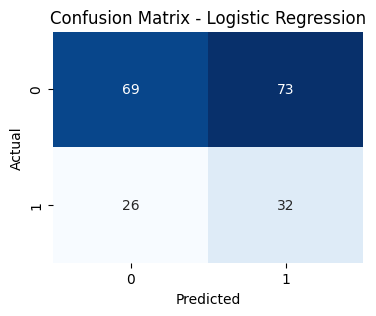

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.49      0.58       142
           1       0.30      0.55      0.39        58

    accuracy                           0.51       200
   macro avg       0.52      0.52      0.49       200
weighted avg       0.60      0.51      0.53       200


--- Training Decision Tree ---


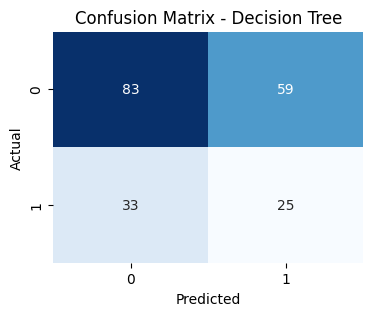

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.58      0.64       142
           1       0.30      0.43      0.35        58

    accuracy                           0.54       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.59      0.54      0.56       200


--- Training Random Forest ---


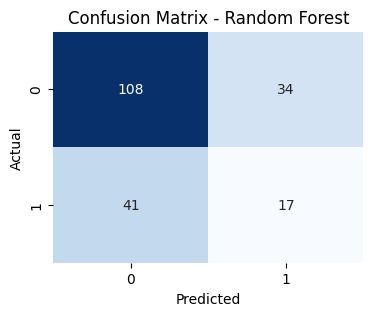

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74       142
           1       0.33      0.29      0.31        58

    accuracy                           0.62       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.61      0.62      0.62       200


--- Training Extra Trees ---


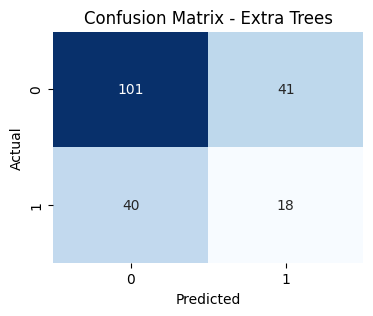

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.71      0.71       142
           1       0.31      0.31      0.31        58

    accuracy                           0.59       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.60      0.60      0.60       200


--- Training KNN ---


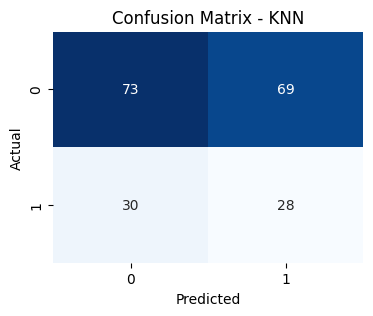

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.51      0.60       142
           1       0.29      0.48      0.36        58

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.48       200
weighted avg       0.59      0.51      0.53       200


--- Training Naive Bayes ---


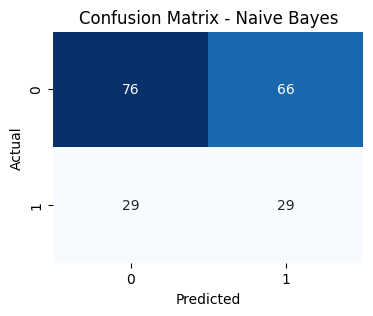

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.54      0.62       142
           1       0.31      0.50      0.38        58

    accuracy                           0.53       200
   macro avg       0.51      0.52      0.50       200
weighted avg       0.60      0.53      0.55       200


--- Training MLP ---


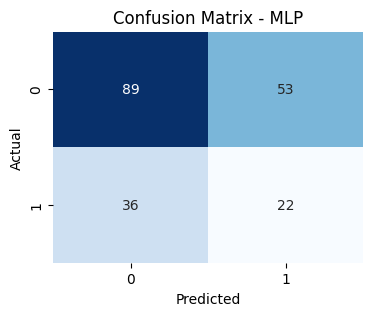

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.63      0.67       142
           1       0.29      0.38      0.33        58

    accuracy                           0.56       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.59      0.56      0.57       200


--- Training Gradient Boosting ---


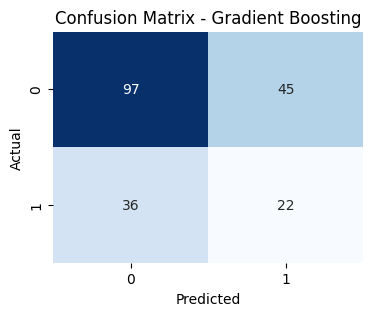

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.68      0.71       142
           1       0.33      0.38      0.35        58

    accuracy                           0.59       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.61      0.59      0.60       200


--- Training AdaBoost ---


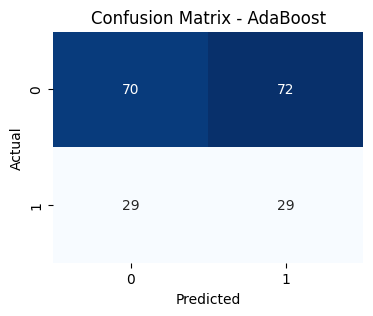

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.49      0.58       142
           1       0.29      0.50      0.36        58

    accuracy                           0.49       200
   macro avg       0.50      0.50      0.47       200
weighted avg       0.59      0.49      0.52       200



In [ ]:
results = []

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_imputed)
    y_proba = model.predict_proba(X_test_imputed)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3),
        "ROC-AUC": round(roc, 3)
    })

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("Classification Report:\n", classification_report(y_test, y_pred))
